# 05 — Modeling: Baseline vs Real Model
Same validation split for both, so the comparison is fair.

In [1]:
import sys
sys.path.insert(0, "..")
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

train = pd.read_parquet("data_cache/train.parquet")
val = pd.read_parquet("data_cache/val.parquet")

feature_cols = [c for c in train.columns if c not in
                ("page_id", "label", "pct_change", "early_clicks", "late_clicks")]
X_train, y_train = train[feature_cols], train["label"]
X_val, y_val = val[feature_cols], val["label"]
feature_cols

['avg_clicks',
 'avg_impressions',
 'avg_ctr',
 'avg_position',
 'std_clicks',
 'word_count',
 'days_since_publish',
 'trend_slope',
 'cat_blog',
 'cat_comparison',
 'cat_faq',
 'cat_guide',
 'cat_landing',
 'cat_product']

In [2]:
# --- Baseline: dumb rule, no ML ---
# "declining if trend_slope < 0, growing if trend_slope > 0, else stable"
def baseline_predict(X):
    preds = []
    for slope in X["trend_slope"]:
        if slope > 2:
            preds.append("growing")
        elif slope < -2:
            preds.append("declining")
        else:
            preds.append("stable")
    return preds

baseline_preds = baseline_predict(X_val)
print("Baseline accuracy:", round(accuracy_score(y_val, baseline_preds), 3))
print(classification_report(y_val, baseline_preds, zero_division=0))

Baseline accuracy: 0.368
              precision    recall  f1-score   support

   declining       0.32      0.48      0.39        25
     growing       0.22      0.46      0.30        24
      stable       0.59      0.30      0.40        76

    accuracy                           0.37       125
   macro avg       0.38      0.41      0.36       125
weighted avg       0.47      0.37      0.38       125



In [3]:
# --- Real model: Gradient Boosted Trees ---
model = GradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)
model_preds = model.predict(X_val)

print("Model accuracy:", round(accuracy_score(y_val, model_preds), 3))
print(classification_report(y_val, model_preds, zero_division=0))

Model accuracy: 0.544
              precision    recall  f1-score   support

   declining       0.22      0.08      0.12        25
     growing       0.22      0.08      0.12        24
      stable       0.60      0.84      0.70        76

    accuracy                           0.54       125
   macro avg       0.35      0.34      0.31       125
weighted avg       0.45      0.54      0.47       125



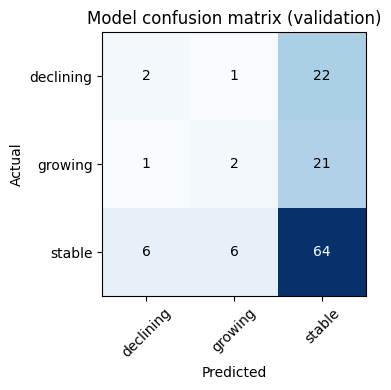

In [4]:
# Confusion matrix for the model
labels_order = sorted(y_val.unique())
cm = confusion_matrix(y_val, model_preds, labels=labels_order)

fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels_order))); ax.set_xticklabels(labels_order, rotation=45)
ax.set_yticks(range(len(labels_order))); ax.set_yticklabels(labels_order)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
for i in range(len(labels_order)):
    for j in range(len(labels_order)):
        ax.text(j, i, cm[i,j], ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black")
ax.set_title("Model confusion matrix (validation)")
plt.tight_layout()
plt.savefig("../docs/assets/confusion_matrix.png", dpi=150)
plt.show()

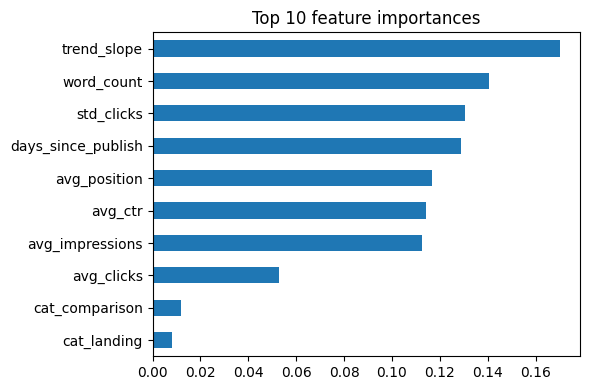

In [5]:
# Feature importance
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values()
fig, ax = plt.subplots(figsize=(6,4))
importances.tail(10).plot.barh(ax=ax)
ax.set_title("Top 10 feature importances")
plt.tight_layout()
plt.savefig("../docs/assets/feature_importance.png", dpi=150)
plt.show()

In [6]:
import joblib, os
os.makedirs("data_cache", exist_ok=True)
joblib.dump(model, "data_cache/model.joblib")
joblib.dump(feature_cols, "data_cache/feature_cols.joblib")
print("Model saved.")

Model saved.
